## Persiapan LIBRARY

In [1]:
!pip install requests beautifulsoup4 pandas lxml country_converter openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 1.3 MB/s eta 0:00:00


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import country_converter as coco
from io import StringIO

In [3]:
url = "https://www.worldometers.info/geography/alphabetical-list-of-countries/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/153.0.0.0 Safari/537.36"
}

print(url)

https://www.worldometers.info/geography/alphabetical-list-of-countries/


In [4]:
import requests
response = requests.get(
    url,
    headers=headers,
    timeout=30
)

print("Status code:", response.status_code)

Status code: 200


In [ ]:
if response.status_code == 200:
    print("Halaman berhasil diakses.")
else:
    print("Gagal mengakses halaman.")
    print("Status code:", response.status_code)

Halaman berhasil diakses.


In [ ]:
soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print("BeautifulSoup berhasil dibuat.")

BeautifulSoup berhasil dibuat.


In [ ]:
tables = soup.find_all("table")

print("Jumlah tabel:", len(tables))

Jumlah tabel: 1


In [ ]:
for i, table in enumerate(tables):
    headers_table = [
        th.get_text(" ", strip=True)
        for th in table.find_all("th")
    ]

    print("Table", i)
    print(headers_table)
    print()

Table 0
['#', 'Country', 'Population 2026', 'Land Area (KmÂ²)', 'Density (P/KmÂ²)']



In [ ]:
for i, table in enumerate(tables):
    headers_table = [
        th.get_text(" ", strip=True)
        for th in table.find_all("th")
    ]

    print("Table", i)
    print(headers_table)
    print()

Table 0
['#', 'Country', 'Population 2026', 'Land Area (KmÂ²)', 'Density (P/KmÂ²)']



In [ ]:
country_table = None

for table in tables:
    headers_table = [
        th.get_text(" ", strip=True)
        for th in table.find_all("th")
    ]

    if "Country" in headers_table and "Land Area (KmÂ²)" in headers_table:
        country_table = table
        break

if country_table is not None:
    print("Tabel negara berhasil ditemukan.")
else:
    print("Tabel negara tidak ditemukan.")

Tabel negara berhasil ditemukan.


In [ ]:
rows = []

for tr in country_table.find_all("tr"):
    cells = [
        cell.get_text(" ", strip=True)
        for cell in tr.find_all(["th", "td"])
    ]

    if cells:
        rows.append(cells)

print("Jumlah baris:", len(rows))

Jumlah baris: 196


In [ ]:
df = pd.DataFrame(
    rows[1:],
    columns=rows[0]
)

df.head()

,#,Country,Population 2026,Land Area (KmÂ²),Density (P/KmÂ²)
0,1,Afghanistan,"45,047,069","652,860",69
1,2,Albania,"2,751,025","27,400",100
2,3,Algeria,"48,028,334","2,381,740",20
3,4,Andorra,"83,753",470,178
4,5,Angola,"40,215,179","1,246,700",32


In [ ]:
print(df.shape)
print()
print(df.columns.tolist())

(195, 5)

['#', 'Country', 'Population 2026', 'Land Area (KmÂ²)', 'Density (P/KmÂ²)']


In [ ]:
print(
    "Jumlah Country unik:",
    df["Country"].nunique()
)

Jumlah Country unik: 195


In [ ]:
df= df.rename(columns={
    'Land Area (KmÂ²)':'Land Area (Km²)',
    'Density (P/KmÂ²)':'Density (P/Km²)'
})
df.describe()



,#,Country,Population 2026,Land Area (Km²),Density (P/Km²)
count,195,195,195,195,195
unique,195,195,195,193,143
top,1,Afghanistan,"45,047,069",700,4
freq,1,1,1,2,7


In [ ]:
df.isnull().sum()

,0
#,0
Country,0
Population 2026,0
Land Area (Km²),0
Density (P/Km²),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_columns = [
    "Population 2026",
    "Land Area (Km²)",
    "Density (P/Km²)"
]

for column in numeric_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("−", "-", regex=False)
    )

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   #                195 non-null    object
 1   Country          195 non-null    object
 2   Population 2026  195 non-null    int64 
 3   Land Area (Km²)  195 non-null    int64 
 4   Density (P/Km²)  195 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.7+ KB


In [ ]:
df["Continent"] = coco.convert(
    df["Country"],
    to="continent"

)

df[
    ["Country", "Continent"]
].head(20)

,Country,Continent
0,Afghanistan,Asia
1,Albania,Europe
2,Algeria,Africa
3,Andorra,Europe
4,Angola,Africa
5,Antigua and Barbuda,America
6,Argentina,America
7,Armenia,Asia
8,Australia,Oceania
9,Austria,Europe


In [ ]:
df["Continent"].value_counts()

,count
Continent,
Africa,54
Asia,48
Europe,44
America,35
Oceania,14


In [ ]:
not_found_continent = df[
    df["Continent"] == "not found"
]

not_found_continent[
    ["Country", "Continent"]
]

,Country,Continent


## POPULASI

In [ ]:
population_url = "https://ourworldindata.org/grapher/population-with-un-projections.csv?v=1&csvType=full&useColumnShortNames=true"

print("URL population sudah disiapkan.")

URL population sudah disiapkan.


In [ ]:
import requests

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    population_url,
    headers=headers
)

print("Status code:", response.status_code)

Status code: 200


In [ ]:
population_df = pd.read_csv(
    StringIO(response.text)
)

population_df.head()

,entity,code,year,population__sex_all__age_all__variant_estimates,population__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,7776180.0,NaN
1,Afghanistan,AFG,1951,7879343.0,NaN
2,Afghanistan,AFG,1952,7987784.0,NaN
3,Afghanistan,AFG,1953,8096703.0,NaN
4,Afghanistan,AFG,1954,8207954.0,NaN


In [ ]:
print(population_df.columns.tolist())

['entity', 'code', 'year', 'population__sex_all__age_all__variant_estimates', 'population__sex_all__age_all__variant_medium__projected']


In [ ]:
population_df["Population"] = (
    population_df[
        "population__sex_all__age_all__variant_estimates"
    ]
    .fillna(
        population_df[
            "population__sex_all__age_all__variant_medium__projected"
        ]
    )
)

population_df.head()

,entity,code,year,population__sex_all__age_all__variant_estimates,population__sex_all__age_all__variant_medium__projected,Population
0,Afghanistan,AFG,1950,7776180.0,NaN,7776180.0
1,Afghanistan,AFG,1951,7879343.0,NaN,7879343.0
2,Afghanistan,AFG,1952,7987784.0,NaN,7987784.0
3,Afghanistan,AFG,1953,8096703.0,NaN,8096703.0
4,Afghanistan,AFG,1954,8207954.0,NaN,8207954.0


In [ ]:
population_df = population_df.rename(
    columns={
        "entity": "Country",
        "year": "Year"
    }
)

population_df.head()

,Country,code,Year,population__sex_all__age_all__variant_estimates,population__sex_all__age_all__variant_medium__projected,Population
0,Afghanistan,AFG,1950,7776180.0,NaN,7776180.0
1,Afghanistan,AFG,1951,7879343.0,NaN,7879343.0
2,Afghanistan,AFG,1952,7987784.0,NaN,7987784.0
3,Afghanistan,AFG,1953,8096703.0,NaN,8096703.0
4,Afghanistan,AFG,1954,8207954.0,NaN,8207954.0


In [ ]:
population_df = population_df[
    [
        "Country",
        "Year",
        "Population"
    ]
]

population_df.head()

,Country,Year,Population
0,Afghanistan,1950,7776180.0
1,Afghanistan,1951,7879343.0
2,Afghanistan,1952,7987784.0
3,Afghanistan,1953,8096703.0
4,Afghanistan,1954,8207954.0


In [ ]:
print("Jumlah baris:", population_df.shape[0])
print("Jumlah kolom:", population_df.shape[1])

Jumlah baris: 39562
Jumlah kolom: 3


In [ ]:
print(
    "Jumlah negara/entitas unik:",
    population_df["Country"].nunique()
)

Jumlah negara/entitas unik: 262


In [ ]:
print("DATA PERTAMA")
print(sorted(df["Country"].unique()))

print("\nDATA KEDUA")
print(sorted(population_df["Country"].unique()))


DATA PERTAMA
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo (Congo-Brazzaville)', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia (Czech Republic)', "CÃ´te d'Ivoire", 'Democratic Republic of the Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini (fmr. ""Swaziland"")', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Holy See', 'Hondu

In [ ]:
print("Tahun awal :", population_df["Year"].min())
print("Tahun akhir:", population_df["Year"].max())

Tahun awal : 1950
Tahun akhir: 2100


In [ ]:
population_country = population_df[
    population_df["Country"].isin(df["Country"])
].copy()

In [ ]:
country_mapping = {
    "Cape Verde": "Cabo Verde",
    "Cote d'Ivoire": "CÃ´te d'Ivoire",
    "Czechia": "Czechia (Czech Republic)",
    "Democratic Republic of Congo": "Democratic Republic of the Congo",
    "East Timor": "Timor-Leste",
    "Eswatini": 'Eswatini (fmr. ""Swaziland"")',
    "Micronesia (country)": "Micronesia",
    "Myanmar": "Myanmar (formerly Burma)",
    "Palestine": "Palestine State",
    "United States": "United States of America",
    "Vatican": "Holy See"
}

In [ ]:
population_df["Country"] = population_df["Country"].replace(
    country_mapping
)

In [ ]:
population_country = population_df[
    population_df["Country"].isin(df["Country"])
].copy()

In [ ]:
print(
    "Jumlah negara data pertama:",
    df["Country"].nunique()
)

print(
    "Jumlah negara population setelah filter:",
    population_country["Country"].nunique()
)

Jumlah negara data pertama: 195
Jumlah negara population setelah filter: 194


In [ ]:
missing = sorted(
    set(df["Country"]) -
    set(population_country["Country"])
)

print("Jumlah negara yang belum match:", len(missing))
print(missing)

Jumlah negara yang belum match: 1
['Congo (Congo-Brazzaville)']


In [ ]:
country_mapping["Congo"] = "Congo (Congo-Brazzaville)"

In [ ]:
population_df["Country"] = population_df["Country"].replace(
    country_mapping
)

In [ ]:
population_country = population_df[
    population_df["Country"].isin(df["Country"])
].copy()

In [ ]:
missing = sorted(
    set(df["Country"]) -
    set(population_country["Country"])
)

print("Jumlah negara yang belum match:", len(missing))
print(missing)

Jumlah negara yang belum match: 0
[]


In [ ]:
print(
    "Jumlah negara data pertama:",
    df["Country"].nunique()
)

print(
    "Jumlah negara population setelah filter:",
    population_country["Country"].nunique()
)

Jumlah negara data pertama: 195
Jumlah negara population setelah filter: 195


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   #                195 non-null    object
 1   Country          195 non-null    object
 2   Population 2026  195 non-null    int64 
 3   Land Area (Km²)  195 non-null    int64 
 4   Density (P/Km²)  195 non-null    int64 
 5   Continent        195 non-null    object
dtypes: int64(3), object(3)
memory usage: 9.3+ KB


In [ ]:
country_info = df[
    ["Country", "Land Area (Km²)", "Continent"]
].copy()

In [ ]:
country_info.head()

,Country,Land Area (Km²),Continent
0,Afghanistan,652860,Asia
1,Albania,27400,Europe
2,Algeria,2381740,Africa
3,Andorra,470,Europe
4,Angola,1246700,Africa


In [ ]:
population_country = population_df[
    population_df["Country"].isin(df["Country"])
].copy()

print("Jumlah negara:", population_country["Country"].nunique())
print("Jumlah tahun :", population_country["Year"].nunique())


Jumlah negara: 195
Jumlah tahun : 151


In [ ]:
population_full = population_country.merge(
    country_info,
    on="Country",
    how="left"
)

In [ ]:
population_full["Density (P/Km²)"] = (
    population_full["Population"] /
    population_full["Land Area (Km²)"]
).round(2)

In [ ]:
population_full = population_full[
    [
        "Country",
        "Continent",
        "Year",
        "Population",
        "Land Area (Km²)",
        "Density (P/Km²)"
    ]
]


In [ ]:
population_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29445 entries, 0 to 29444
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          29445 non-null  object 
 1   Continent        29445 non-null  object 
 2   Year             29445 non-null  int64  
 3   Population       29445 non-null  float64
 4   Land Area (Km²)  29445 non-null  int64  
 5   Density (P/Km²)  29445 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.3+ MB


In [ ]:
population_full.head()

,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²)
0,Afghanistan,Asia,1950,7776180.0,652860,11.91
1,Afghanistan,Asia,1951,7879343.0,652860,12.07
2,Afghanistan,Asia,1952,7987784.0,652860,12.24
3,Afghanistan,Asia,1953,8096703.0,652860,12.40
4,Afghanistan,Asia,1954,8207954.0,652860,12.57


In [ ]:
population_full[
    population_full["Country"] == "Singapore"
].sort_values("Year", ascending=True).head(20)

,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²)
23556,Singapore,Asia,1950,1013318.0,700,1447.60
23557,Singapore,Asia,1951,1068050.0,700,1525.79
23558,Singapore,Asia,1952,1126098.0,700,1608.71
23559,Singapore,Asia,1953,1187531.0,700,1696.47
23560,Singapore,Asia,1954,1252286.0,700,1788.98
23561,Singapore,Asia,1955,1320233.0,700,1886.05
23562,Singapore,Asia,1956,1390957.0,700,1987.08
23563,Singapore,Asia,1957,1458281.0,700,2083.26
23564,Singapore,Asia,1958,1515731.0,700,2165.33
23565,Singapore,Asia,1959,1567757.0,700,2239.65


In [ ]:
print("Total baris:", len(population_full))
print("Jumlah negara:", population_full["Country"].nunique())
print("Jumlah tahun:", population_full["Year"].nunique())

Total baris: 29445
Jumlah negara: 195
Jumlah tahun: 151


In [ ]:
population_full.isna().sum()

,0
Country,0
Continent,0
Year,0
Population,0
Land Area (Km²),0
Density (P/Km²),0


In [ ]:
population_full.isnull().sum()

,0
Country,0
Continent,0
Year,0
Population,0
Land Area (Km²),0
Density (P/Km²),0


In [ ]:
population_final = population_full[
    population_full["Year"] >= 2011
].copy()

In [ ]:
print("Jumlah negara:", population_final["Country"].nunique())
print("Tahun awal:", population_final["Year"].min())
print("Tahun akhir:", population_final["Year"].max())
print("Jumlah baris:", len(population_final))

Jumlah negara: 195
Tahun awal: 2011
Tahun akhir: 2100
Jumlah baris: 17550


In [ ]:
url_happiness = "https://worldhappiness.report/ed/2025/"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/131.0 Safari/537.36"
}

response_happiness = requests.get(
    url_happiness,
    headers=headers
)

print(response_happiness.status_code)


200


In [ ]:
soup_happiness = BeautifulSoup(
    response_happiness.text,
    "html.parser"
)

print(soup_happiness.title)

<title>World Happiness Report 2025 | The World Happiness Report</title>


In [ ]:
happiness_tables = soup_happiness.find_all("table")

print("Jumlah tabel:", len(happiness_tables))

Jumlah tabel: 0


In [ ]:
links = soup_happiness.find_all("a")

for link in links:
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    if text:
        print(text[:100], "->", href)

Skip to Main Content -> #main
Home -> /
About -> /about/
FAQ -> /faq/
Data -> https://data.worldhappiness.report
Analysis -> /analysis/
News -> /news/
Subscribe -> /subscribe
Bluesky Follow the WHR on Bluesky -> https://bsky.app/profile/worldhappiness.report
Instagram Follow the WHR on Instagram -> https://www.instagram.com/happinessrpt/
LinkedIn Follow the WHR on LinkedIn -> https://www.linkedin.com/company/76752696
Twitter / X Follow the WHR on X/Twitter -> https://twitter.com/HappinessRpt
YouTube Follow the WHR on YouTube -> https://www.youtube.com/@world-happiness-report
Chapter 1 Executive Summary -> /ed/2025/executive-summary/
Chapter 2 Caring and sharing: Global analysis of happiness and kindness -> /ed/2025/caring-and-sharing-global-analysis-of-happiness-and-kindness/
Chapter 3 Sharing meals with others: How sharing meals supports happiness and social connections -> /ed/2025/sharing-meals-with-others-how-sharing-meals-supports-happiness-and-social-connections/
Chapter 4 Living 

In [ ]:
for link in links:
    text = link.get_text(" ", strip=True).lower()
    href = link.get("href")

    if any(x in text for x in ["data", "download", "figure 2.1"]):
        print(text, "->", href)

data -> https://data.worldhappiness.report
download pdf (pdf) -> https://files.worldhappiness.report/WHR25.pdf
appendices & data -> #appendices-and-data
data for figure 2.1 -> https://files.worldhappiness.report/WHR25_Data_Figure_2.1v3.xlsx
data-sharing page -> /data-sharing/
data -> https://data.worldhappiness.report


In [ ]:
data_url = None

for link in links:
    text = link.get_text(" ", strip=True).lower()
    href = link.get("href")

    if "data for figure 2.1" in text:
        data_url = href
        break

print(data_url)

https://files.worldhappiness.report/WHR25_Data_Figure_2.1v3.xlsx


In [ ]:
response_data = requests.get(
    data_url,
    headers=headers
)

print(response_data.status_code)
print(len(response_data.content))

200
149058


In [ ]:
with open("WHR25_Data_Figure_2.1v3.xlsx", "wb") as f:
    f.write(response_data.content)

print("File berhasil disimpan")

File berhasil disimpan


In [ ]:
happiness_raw = pd.read_excel(
    "WHR25_Data_Figure_2.1v3.xlsx"
)

happiness_raw.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,147,Afghanistan,1.364,1.301,1.427,0.649,0.0,0.155,0.0,0.075,0.135,0.348
1,2023,143,Afghanistan,1.721,1.667,1.775,0.628,0.0,0.242,0.0,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,1.795,1.923,0.645,0.0,0.087,0.0,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,2.339,2.469,0.758,0.0,0.289,0.0,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,2.449,2.596,0.370,0.0,0.126,0.0,0.122,0.010,1.895


In [ ]:
print(happiness_raw.columns.tolist())

['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']


In [ ]:
happiness_raw = pd.read_excel(
    "WHR25_Data_Figure_2.1v3.xlsx"
)
happiness_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        1969 non-null   int64  
 1   Rank                                        1969 non-null   int64  
 2   Country name                                1969 non-null   object 
 3   Life evaluation (3-year average)            1969 non-null   float64
 4   Lower whisker                               875 non-null    float64
 5   Upper whisker                               875 non-null    float64
 6   Explained by: Log GDP per capita            872 non-null    float64
 7   Explained by: Social support                872 non-null    float64
 8   Explained by: Healthy life expectancy       870 non-null    float64
 9   Explained by: Freedom to make life choices  871 non-null    float64
 10  Explained by

In [ ]:
happiness_df = happiness_raw.copy()
happiness_df = happiness_df.rename(columns={
    "Rank": "Happiness Rank",
    "Country name": "Country",
    "Life evaluation (3-year average)": "Happiness Score"
})

happiness_df = happiness_df.rename(columns={
    "Explained by: Log GDP per capita": "GDP_per_Capita",
    "Explained by: Social support": "Social_Support",
    "Explained by: Healthy life expectancy": "Healthy_Life_Expectancy",
    "Explained by: Freedom to make life choices": "Freedom",
    "Explained by: Generosity": "Generosity",
    "Explained by: Perceptions of corruption": "Perceptions_of_Corruption",
    "Dystopia + residual": "Dystopia_Residual"
})
happiness_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       1969 non-null   int64  
 1   Happiness Rank             1969 non-null   int64  
 2   Country                    1969 non-null   object 
 3   Happiness Score            1969 non-null   float64
 4   Lower whisker              875 non-null    float64
 5   Upper whisker              875 non-null    float64
 6   GDP_per_Capita             872 non-null    float64
 7   Social_Support             872 non-null    float64
 8   Healthy_Life_Expectancy    870 non-null    float64
 9   Freedom                    871 non-null    float64
 10  Generosity                 872 non-null    float64
 11  Perceptions_of_Corruption  871 non-null    float64
 12  Dystopia_Residual          868 non-null    float64
dtypes: float64(10), int64(2), object(1)
memory usage

In [ ]:
population_final = population_full[
    population_full["Year"] >= 2011
].copy()

In [ ]:
print(population_final["Year"].min())
print(population_final["Year"].max())

2011
2100


In [ ]:
population_final["Year"] = population_final["Year"].astype(int)
happiness_df["Year"] = happiness_df["Year"].astype(int)

In [ ]:
missing_happiness = sorted(
    set(happiness_df["Country"]) -
    set(df["Country"])
)

print("Jumlah belum match:", len(missing_happiness))
print(missing_happiness)

Jumlah belum match: 21
['Congo', 'Czechia', 'Côte d’Ivoire', 'DR Congo', 'Eswatini', 'Hong Kong SAR of China', 'Kosovo', 'Lao PDR', 'Myanmar', 'North Cyprus', 'Puerto Rico', 'Republic of Korea', 'Republic of Moldova', 'Russian Federation', 'Somaliland Region', 'State of Palestine', 'Swaziland', 'Taiwan Province of China', 'Türkiye', 'United States', 'Viet Nam']


In [ ]:
happiness_mapping = {
    "Congo": "Congo (Congo-Brazzaville)",
    "Czechia": "Czechia (Czech Republic)",
    "Côte d’Ivoire": "CÃ´te d'Ivoire",
    "DR Congo": "Democratic Republic of the Congo",
    "Eswatini": 'Eswatini (fmr. ""Swaziland"")',
    "Hong Kong SAR of China": None,
    "Kosovo": None,
    "Lao PDR": "Laos",
    "Myanmar": "Myanmar (formerly Burma)",
    "North Cyprus": None,
    "Puerto Rico": None,
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "Somaliland Region": None,
    "State of Palestine": "Palestine State",
    "Swaziland": 'Eswatini (fmr. ""Swaziland"")',
    "Taiwan Province of China": None,
    "Türkiye": "Turkey",
    "United States": "United States of America",
    "Viet Nam": "Vietnam"
}


happiness_df["Country"] = happiness_df["Country"].replace(
    happiness_mapping
)

In [ ]:
happiness_df = happiness_df[
    happiness_df["Country"].notna()
].copy()

In [ ]:
missing_happiness = sorted(
    set(happiness_df["Country"]) -
    set(df["Country"])
)

print("Jumlah belum match:", len(missing_happiness))
print(missing_happiness)

Jumlah belum match: 0
[]


In [ ]:
missing_in_happiness = sorted(
    set(df["Country"]) -
    set(happiness_df["Country"])
)

print(
    "Negara dari data pertama yang tidak ada di Happiness:",
    len(missing_in_happiness)
)

print(missing_in_happiness)

Negara dari data pertama yang tidak ada di Happiness: 34
['Andorra', 'Antigua and Barbuda', 'Bahamas', 'Barbados', 'Brunei', 'Cabo Verde', 'Dominica', 'Equatorial Guinea', 'Eritrea', 'Fiji', 'Grenada', 'Guinea-Bissau', 'Holy See', 'Kiribati', 'Liechtenstein', 'Marshall Islands', 'Micronesia', 'Monaco', 'Nauru', 'North Korea', 'Palau', 'Papua New Guinea', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Samoa', 'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Solomon Islands', 'Timor-Leste', 'Tonga', 'Tuvalu', 'Vanuatu']


In [ ]:
final_df = population_final.merge(
    happiness_df,
    on=["Country", "Year"],
    how="left"
)

In [ ]:
print("Jumlah negara:", final_df["Country"].nunique())

Jumlah negara: 195


In [ ]:
print(
    "Tahun:",
    final_df["Year"].min(),
    "-",
    final_df["Year"].max()
)

Tahun: 2011 - 2100


In [ ]:
final_df[
    final_df["Country"] == "Japan"
].sort_values("Year", ascending=False).head(10)

,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score,Lower whisker,Upper whisker,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption,Dystopia_Residual
7739,Japan,Asia,2100,76845989.0,364555,210.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7738,Japan,Asia,2099,77230868.0,364555,211.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7737,Japan,Asia,2098,77612888.0,364555,212.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7736,Japan,Asia,2097,77990637.0,364555,213.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7735,Japan,Asia,2096,78369014.0,364555,214.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7734,Japan,Asia,2095,78747735.0,364555,216.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7733,Japan,Asia,2094,79123890.0,364555,217.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7732,Japan,Asia,2093,79500577.0,364555,218.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7731,Japan,Asia,2092,79879693.0,364555,219.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7730,Japan,Asia,2091,80257720.0,364555,220.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_df[
    final_df["Country"] == "Japan"
].sort_values("Year", ascending=False).tail(10)

,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score,Lower whisker,Upper whisker,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption,Dystopia_Residual
7659,Japan,Asia,2020,126304533.0,364555,346.46,57.0,5.9400,5.861000,6.020000,1.389000,0.949000,0.838000,0.504000,0.020000,0.19200,2.0480
7658,Japan,Asia,2019,126699421.0,364555,347.55,62.0,5.8708,5.789672,5.951928,1.266724,1.332339,1.072881,0.495466,0.035712,0.18144,1.4862
7657,Japan,Asia,2018,126913432.0,364555,348.13,58.0,5.8860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7656,Japan,Asia,2017,127064686.0,364555,348.55,54.0,5.9150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7655,Japan,Asia,2016,127159950.0,364555,348.81,51.0,5.9200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7654,Japan,Asia,2015,127275868.0,364555,349.13,53.0,5.9210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7653,Japan,Asia,2014,127486601.0,364555,349.70,46.0,5.9870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7652,Japan,Asia,2013,127723642.0,364555,350.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7651,Japan,Asia,2012,127928283.0,364555,350.92,43.0,6.0640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7650,Japan,Asia,2011,128096430.0,364555,351.38,44.0,6.0590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(
    "Baris dengan Happiness:",
    final_df["Happiness Score"].notna().sum()
)

print(
    "Baris tanpa Happiness:",
    final_df["Happiness Score"].isna().sum()
)

Baris dengan Happiness: 1915
Baris tanpa Happiness: 15635


In [ ]:
print(
    "Negara yang punya Happiness:",
    final_df.loc[
        final_df["Happiness Score"].notna(),
        "Country"
    ].nunique()
)

Negara yang punya Happiness: 161


In [ ]:
print(
    "Duplicate Country + Year:",
    final_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)

Duplicate Country + Year: 0


In [ ]:
happiness_analysis = final_df[
    final_df["Happiness Score"].notna()
].copy()

In [ ]:
print(happiness_analysis.shape)
print(happiness_analysis["Country"].nunique())
print(happiness_analysis["Year"].min())
print(happiness_analysis["Year"].max())

(1915, 17)
161
2011
2024


In [ ]:
print("=== DATASET UTAMA ===")
print("Negara :", final_df["Country"].nunique())
print("Tahun  :", final_df["Year"].min(), "-", final_df["Year"].max())
print("Baris  :", len(final_df))

print("\n=== HAPPINESS ===")
print("Negara :", happiness_analysis["Country"].nunique())
print("Tahun  :", happiness_analysis["Year"].min(), "-", happiness_analysis["Year"].max())
print("Baris  :", len(happiness_analysis))

=== DATASET UTAMA ===
Negara : 195
Tahun  : 2011 - 2100
Baris  : 17550

=== HAPPINESS ===
Negara : 161
Tahun  : 2011 - 2024
Baris  : 1915


In [ ]:
final_df.isna().sum()

,0
Country,0
Continent,0
Year,0
Population,0
Land Area (Km²),0
Density (P/Km²),0
Happiness Rank,15635
Happiness Score,15635
Lower whisker,16696
Upper whisker,16696


In [ ]:
print(
    happiness_raw["Year"].unique()
)
print(
    happiness_raw["Year"].value_counts().sort_index()
)


[2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2012 2011]
Year
2011    156
2012    156
2014    158
2015    157
2016    155
2017    156
2018    156
2019    153
2020    149
2021    146
2022    137
2023    143
2024    147
Name: count, dtype: int64


In [ ]:
print(sorted(happiness_df["Year"].unique()))

[np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
happiness_df = happiness_df[
    happiness_df["Year"] >= 2011
].copy()

happiness_df["Year"] = happiness_df["Year"].astype(int)
happiness_df.columns.tolist()


['Year',
 'Happiness Rank',
 'Country',
 'Happiness Score',
 'Lower whisker',
 'Upper whisker',
 'GDP_per_Capita',
 'Social_Support',
 'Healthy_Life_Expectancy',
 'Freedom',
 'Generosity',
 'Perceptions_of_Corruption',
 'Dystopia_Residual']

In [ ]:
print(sorted(happiness_df["Year"].unique()))

[np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
%whos

Variable               Type              Data/Info
--------------------------------------------------
BeautifulSoup          type              <class 'bs4.BeautifulSoup'>
StringIO               type              <class '_io.StringIO'>
cells                  list              n=5
coco                   module            <module 'country_converte<...>y_converter/__init__.py'>
cols                   set               {'Country', 'Continent', <...>Year', 'Density (P/Km²)'}
column                 str               Density (P/Km²)
country_info           DataFrame                  Country  Land Ar<...>n\n[195 rows x 3 columns]
country_mapping        dict              n=12
country_table          Tag               <table class="datatable w<...>> </tr> </tbody> </table>
data_url               str               https://files.worldhappin<...>25_Data_Figure_2.1v3.xlsx
df                     DataFrame                #      Country  Po<...>n\n[195 rows x 6 columns]
excel                  ExcelFile   

In [ ]:
# Cari dataframe yang kemungkinan berisi data Happiness 2025
for nama in dir():
    obj = globals()[nama]

    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)

        if {
            "Year",
            "Rank",
            "Country name",
            "Life evaluation (3-year average)"
        }.issubset(cols):
            print("Ditemukan:", nama)
            print("Shape:", obj.shape)
            print(obj.head(3))
            print()

Ditemukan: _203
Shape: (5, 13)
   Year  Rank Country name  Life evaluation (3-year average)  Lower whisker  \
0  2024   147  Afghanistan                             1.364          1.301   
1  2023   143  Afghanistan                             1.721          1.667   
2  2022   137  Afghanistan                             1.859          1.795   

   Upper whisker  Explained by: Log GDP per capita  \
0          1.427                             0.649   
1          1.775                             0.628   
2          1.923                             0.645   

   Explained by: Social support  Explained by: Healthy life expectancy  \
0                           0.0                                  0.155   
1                           0.0                                  0.242   
2                           0.0                                  0.087   

   Explained by: Freedom to make life choices  Explained by: Generosity  \
0                                         0.0                  

In [ ]:
file_2025 = "WHR25_Data_Figure_2.1v3.xlsx"

excel = pd.ExcelFile(file_2025)

print(excel.sheet_names)

['Data for Figure 2.1 (2011–2024)']


In [ ]:
print("=== VALIDASI FINAL ===")
print("Jumlah negara :", final_df["Country"].nunique())
print("Tahun         :", final_df["Year"].min(), "-", final_df["Year"].max())
print("Jumlah baris  :", len(final_df))

=== VALIDASI FINAL ===
Jumlah negara : 195
Tahun         : 2011 - 2100
Jumlah baris  : 17550


In [ ]:
tahun_per_negara = final_df.groupby("Country")["Year"].nunique()

print(tahun_per_negara.value_counts().sort_index())

Year
90    195
Name: count, dtype: int64


In [ ]:
print(
    final_df.groupby("Year")["Happiness Score"]
    .count()
)


Year
2011    151
2012    151
2013      0
2014    153
2015    151
       ... 
2096      0
2097      0
2098      0
2099      0
2100      0
Name: Happiness Score, Length: 90, dtype: int64


Year
2011    151
2012    151
2013      0
2014    153
2015    151
       ... 
2096      0
2097      0
2098      0
2099      0
2100      0
Name: Happiness Score, Length: 90, dtype: int64


In [ ]:
print(
    "Duplicate Country + Year:",
    final_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)


Duplicate Country + Year: 0


In [ ]:
# Batasi population hanya 2011–2024
population_2011_2024 = population_final[
    population_final["Year"].between(2011, 2024)
].copy()

# Happiness juga 2011–2024
happiness_2011_2024 = happiness_df[
    happiness_df["Year"].between(2011, 2024)
].copy()

# Merge ulang
final_df = population_2011_2024.merge(
    happiness_2011_2024,
    on=["Country", "Year"],
    how="left"
)

In [ ]:
print("=== VALIDASI FINAL ===")
print("Jumlah negara :", final_df["Country"].nunique())
print("Tahun         :", final_df["Year"].min(), "-", final_df["Year"].max())
print("Jumlah baris   :", len(final_df))

=== VALIDASI FINAL ===
Jumlah negara : 195
Tahun         : 2011 - 2024
Jumlah baris   : 2730


In [ ]:
print(
    final_df.groupby("Year")["Happiness Score"].count()
)

Year
2011    151
2012    151
2013      0
2014    153
2015    151
2016    151
2017    152
2018    152
2019    149
2020    145
2021    142
2022    134
2023    140
2024    144
Name: Happiness Score, dtype: int64


In [ ]:
print(
    "Duplicate Country + Year:",
    final_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)

Duplicate Country + Year: 0


In [ ]:
print(
    final_df.groupby("Country")["Year"].nunique()
    .value_counts()
)


Year
14    195
Name: count, dtype: int64


In [ ]:
final_df = population_final.merge(
    happiness_df,
    on=["Country", "Year"],
    how="left"
)

print("Jumlah negara :", final_df["Country"].nunique())
print("Tahun         :", final_df["Year"].min(), "-", final_df["Year"].max())
print("Jumlah baris   :", len(final_df))


Jumlah negara : 195
Tahun         : 2011 - 2100
Jumlah baris   : 17550


In [ ]:
cek_2025 = final_df[
    final_df["Year"] >= 2025
]

print(
    "Jumlah Happiness terisi 2025–2100:",
    cek_2025["Happiness Score"].notna().sum()
)

Jumlah Happiness terisi 2025–2100: 0


In [ ]:
final_df[
    final_df["Country"] == "Japan"
][[
    "Country",
    "Continent",
    "Year",
    "Population",
    "Land Area (Km²)",
    "Density (P/Km²)",
    "Happiness Rank",
    "Happiness Score"
]].sort_values("Year", ascending=False).head(5)

,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score
7739,Japan,Asia,2100,76845989.0,364555,210.79,NaN,NaN
7738,Japan,Asia,2099,77230868.0,364555,211.85,NaN,NaN
7737,Japan,Asia,2098,77612888.0,364555,212.90,NaN,NaN
7736,Japan,Asia,2097,77990637.0,364555,213.93,NaN,NaN
7735,Japan,Asia,2096,78369014.0,364555,214.97,NaN,NaN


In [ ]:
final_df[
    final_df["Country"] == "Japan"
][[
    "Country",
    "Continent",
    "Year",
    "Population",
    "Land Area (Km²)",
    "Density (P/Km²)",
    "Happiness Rank",
    "Happiness Score"
]].sort_values("Year", ascending=False).tail(5)

,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score
7654,Japan,Asia,2015,127275868.0,364555,349.13,53.0,5.921
7653,Japan,Asia,2014,127486601.0,364555,349.70,46.0,5.987
7652,Japan,Asia,2013,127723642.0,364555,350.35,NaN,NaN
7651,Japan,Asia,2012,127928283.0,364555,350.92,43.0,6.064
7650,Japan,Asia,2011,128096430.0,364555,351.38,44.0,6.059


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17550 entries, 0 to 17549
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    17550 non-null  object 
 1   Continent                  17550 non-null  object 
 2   Year                       17550 non-null  int64  
 3   Population                 17550 non-null  float64
 4   Land Area (Km²)            17550 non-null  int64  
 5   Density (P/Km²)            17550 non-null  float64
 6   Happiness Rank             1915 non-null   float64
 7   Happiness Score            1915 non-null   float64
 8   Lower whisker              854 non-null    float64
 9   Upper whisker              854 non-null    float64
 10  GDP_per_Capita             851 non-null    float64
 11  Social_Support             851 non-null    float64
 12  Healthy_Life_Expectancy    849 non-null    float64
 13  Freedom                    850 non-null    flo

In [ ]:
dataset = final_df.copy()
dataset.to_csv(
    "dataset_country_population_happiness.csv",
    index=False,
    encoding="utf-8-sig"
)
print("=== VALIDASI DATASET ===")
print("Jumlah negara :", dataset["Country"].nunique())
print("Tahun         :", dataset["Year"].min(), "-", dataset["Year"].max())
print("Jumlah baris  :", len(dataset))


=== VALIDASI DATASET ===
Jumlah negara : 195
Tahun         : 2011 - 2100
Jumlah baris  : 17550


# **EKPLORASI ANALISIS DATA HASIL SCRAP**

In [ ]:
from google.colab import files

''' untuk unduh'''
# files.download(
#     "dataset_country_population_happiness.csv"
# )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Shape:", final_df.shape)
display(final_df.head())
display(final_df.tail())

Shape: (17550, 17)


,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score,Lower whisker,Upper whisker,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption,Dystopia_Residual
0,Afghanistan,Asia,2011,29347708.0,652860,44.95,131.0,4.258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,Asia,2012,30560036.0,652860,46.81,143.0,4.040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,Asia,2013,31622709.0,652860,48.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Asia,2014,32792528.0,652860,50.23,153.0,3.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Asia,2015,33831767.0,652860,51.82,154.0,3.360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Country,Continent,Year,Population,Land Area (Km²),Density (P/Km²),Happiness Rank,Happiness Score,Lower whisker,Upper whisker,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption,Dystopia_Residual
17545,Zimbabwe,Africa,2096,36840484.0,386850,95.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17546,Zimbabwe,Africa,2097,36932280.0,386850,95.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17547,Zimbabwe,Africa,2098,37019885.0,386850,95.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17548,Zimbabwe,Africa,2099,37096555.0,386850,95.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17549,Zimbabwe,Africa,2100,37166574.0,386850,96.07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17550 entries, 0 to 17549
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    17550 non-null  object 
 1   Continent                  17550 non-null  object 
 2   Year                       17550 non-null  int64  
 3   Population                 17550 non-null  float64
 4   Land Area (Km²)            17550 non-null  int64  
 5   Density (P/Km²)            17550 non-null  float64
 6   Happiness Rank             1915 non-null   float64
 7   Happiness Score            1915 non-null   float64
 8   Lower whisker              854 non-null    float64
 9   Upper whisker              854 non-null    float64
 10  GDP_per_Capita             851 non-null    float64
 11  Social_Support             851 non-null    float64
 12  Healthy_Life_Expectancy    849 non-null    float64
 13  Freedom                    850 non-null    flo

In [ ]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,17550.0,2.055500e+03,2.597990e+01,2011.000,2.033000e+03,2.055500e+03,2.078000e+03,2.100000e+03
Population,17550.0,4.817985e+07,1.514640e+08,501.000,1.851196e+06,9.909367e+06,4.045534e+07,1.701284e+09
Land Area (Km²),17550.0,6.627831e+05,1.829577e+06,0.000,2.281000e+04,1.127600e+05,5.279700e+05,1.637687e+07
Density (P/Km²),17550.0,inf,NaN,1.770,4.313250e+01,1.010000e+02,2.334900e+02,inf
Happiness Rank,1915.0,7.694987e+01,4.425819e+01,1.000,3.900000e+01,7.700000e+01,1.150000e+02,1.580000e+02
Happiness Score,1915.0,5.440771e+00,1.131793e+00,1.364,4.572550e+00,5.422000e+00,6.282300e+00,7.856000e+00
Lower whisker,854.0,5.405571e+00,1.146876e+00,1.301,4.594787e+00,5.522320e+00,6.232250e+00,7.780000e+00
Upper whisker,854.0,5.636419e+00,1.111549e+00,1.427,4.855903e+00,5.762508e+00,6.441966e+00,7.904000e+00
GDP_per_Capita,851.0,1.212508e+00,4.636558e-01,0.000,8.969935e-01,1.256000e+00,1.558000e+00,2.209000e+00
Social_Support,851.0,1.076495e+00,3.574831e-01,0.000,8.470000e-01,1.106000e+00,1.362000e+00,1.840000e+00


In [ ]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,17550.0,2.055500e+03,2.597990e+01,2011.000,2.033000e+03,2.055500e+03,2.078000e+03,2.100000e+03
Population,17550.0,4.817985e+07,1.514640e+08,501.000,1.851196e+06,9.909367e+06,4.045534e+07,1.701284e+09
Land Area (Km²),17550.0,6.627831e+05,1.829577e+06,0.000,2.281000e+04,1.127600e+05,5.279700e+05,1.637687e+07
Density (P/Km²),17550.0,inf,NaN,1.770,4.313250e+01,1.010000e+02,2.334900e+02,inf
Happiness Rank,1915.0,7.694987e+01,4.425819e+01,1.000,3.900000e+01,7.700000e+01,1.150000e+02,1.580000e+02
Happiness Score,1915.0,5.440771e+00,1.131793e+00,1.364,4.572550e+00,5.422000e+00,6.282300e+00,7.856000e+00
Lower whisker,854.0,5.405571e+00,1.146876e+00,1.301,4.594787e+00,5.522320e+00,6.232250e+00,7.780000e+00
Upper whisker,854.0,5.636419e+00,1.111549e+00,1.427,4.855903e+00,5.762508e+00,6.441966e+00,7.904000e+00
GDP_per_Capita,851.0,1.212508e+00,4.636558e-01,0.000,8.969935e-01,1.256000e+00,1.558000e+00,2.209000e+00
Social_Support,851.0,1.076495e+00,3.574831e-01,0.000,8.470000e-01,1.106000e+00,1.362000e+00,1.840000e+00


In [ ]:
print(
    "Duplicate seluruh baris:",
    final_df.duplicated().sum()
)

print(
    "Duplicate Country + Year:",
    final_df.duplicated(
        subset=["Country", "Year"]
    ).sum()
)

Duplicate seluruh baris: 0
Duplicate Country + Year: 0


In [ ]:
continent_count = (
    final_df[["Country", "Continent"]]
    .drop_duplicates()
    ["Continent"]
    .value_counts()
)

display(continent_count)

,count
Continent,
Africa,54
Asia,48
Europe,44
America,35
Oceania,14


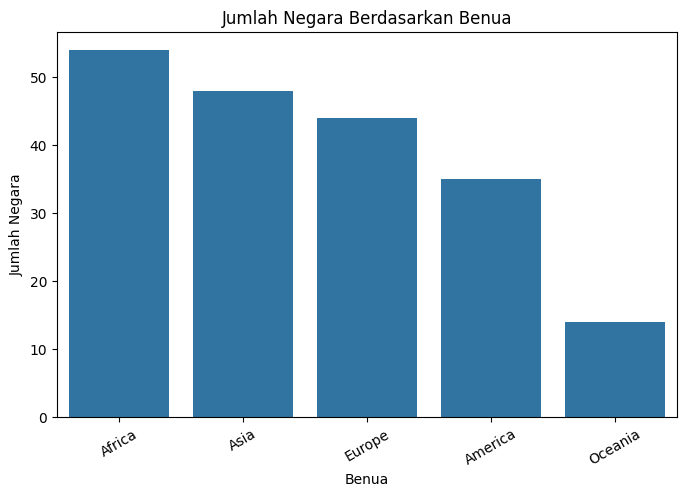

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    x=continent_count.index,
    y=continent_count.values
)

plt.title("Jumlah Negara Berdasarkan Benua")
plt.xlabel("Benua")
plt.ylabel("Jumlah Negara")
plt.xticks(rotation=30)
plt.show()

In [ ]:
population_2024 = final_df[
    final_df["Year"] == 2024
].copy()

population_2024 = population_2024.sort_values(
    "Population",
    ascending=False
)

display(
    population_2024[
        ["Country", "Continent", "Population"]
    ].head(10)
)

,Country,Continent,Population
6943,India,Asia,1.450936e+09
3163,China,Asia,1.419321e+09
16663,United States of America,America,3.454266e+08
7033,Indonesia,Asia,2.834879e+08
11803,Pakistan,Asia,2.512692e+08
11353,Nigeria,Africa,2.326795e+08
2083,Brazil,America,2.119986e+08
1183,Bangladesh,Asia,1.735624e+08
12883,Russia,Europe,1.448204e+08
5233,Ethiopia,Africa,1.320598e+08


In [ ]:
density_2024 = final_df[
    final_df["Year"] == 2024
].sort_values(
    "Density (P/Km²)",
    ascending=False
)

display(
    density_2024[
        ["Country", "Continent", "Population", "Land Area (Km²)", "Density (P/Km²)"]
    ].head(10)
)

,Country,Continent,Population,Land Area (Km²),Density (P/Km²)
17023,Holy See,Europe,507.0,0,inf
10183,Monaco,Europe,38657.0,1,38657.00
14053,Singapore,Asia,5832387.0,700,8331.98
1093,Bahrain,Asia,1607059.0,760,2114.55
9373,Maldives,Asia,527801.0,300,1759.34
9553,Malta,Europe,539612.0,320,1686.29
1183,Bangladesh,Asia,173562366.0,130170,1333.35
11983,Palestine State,Asia,5495447.0,6020,912.86
1273,Barbados,America,282476.0,430,656.92
9823,Mauritius,Africa,1271171.0,2030,626.19


In [ ]:
import numpy as np

dataset["Density (P/Km²)"] = dataset["Density (P/Km²)"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [ ]:
density_2024 = final_df[
    final_df["Year"] == 2024
].sort_values(
    "Density (P/Km²)",
    ascending=False
)

display(
    density_2024[
        ["Country", "Continent", "Population", "Land Area (Km²)", "Density (P/Km²)"]
    ].head(10)
)

,Country,Continent,Population,Land Area (Km²),Density (P/Km²)
17023,Holy See,Europe,507.0,0,inf
10183,Monaco,Europe,38657.0,1,38657.00
14053,Singapore,Asia,5832387.0,700,8331.98
1093,Bahrain,Asia,1607059.0,760,2114.55
9373,Maldives,Asia,527801.0,300,1759.34
9553,Malta,Europe,539612.0,320,1686.29
1183,Bangladesh,Asia,173562366.0,130170,1333.35
11983,Palestine State,Asia,5495447.0,6020,912.86
1273,Barbados,America,282476.0,430,656.92
9823,Mauritius,Africa,1271171.0,2030,626.19


In [ ]:
dataset[
    dataset["Country"] == "Holy See"
][[
    "Country",
    "Year",
    "Population",
    "Land Area (Km²)",
    "Density (P/Km²)"
]].head()

,Country,Year,Population,Land Area (Km²),Density (P/Km²)
17010,Holy See,2011,624.0,0,NaN
17011,Holy See,2012,612.0,0,NaN
17012,Holy See,2013,598.0,0,NaN
17013,Holy See,2014,587.0,0,NaN
17014,Holy See,2015,579.0,0,NaN


In [ ]:
happiness_analysis = final_df[
    final_df["Happiness Score"].notna()
].copy()

print("Shape:", happiness_analysis.shape)

print(
    "Tahun:",
    happiness_analysis["Year"].min(),
    "-",
    happiness_analysis["Year"].max()
)

print(
    "Negara:",
    happiness_analysis["Country"].nunique()
)

Shape: (1915, 17)
Tahun: 2011 - 2024
Negara: 161


In [ ]:
latest_happiness_year = (
    happiness_analysis["Year"].max()
)

latest_happiness = happiness_analysis[
    happiness_analysis["Year"] == latest_happiness_year
].sort_values(
    "Happiness Score",
    ascending=False
)

display(
    latest_happiness[
        [
            "Country",
            "Continent",
            "Happiness Rank",
            "Happiness Score"
        ]
    ].head(10)
)

,Country,Continent,Happiness Rank,Happiness Score
5413,Finland,Europe,1.0,7.736
4153,Denmark,Europe,2.0,7.521
6853,Iceland,Europe,3.0,7.515
15133,Sweden,Europe,4.0,7.345
10993,Netherlands,Europe,5.0,7.306
3523,Costa Rica,America,6.0,7.274
11623,Norway,Europe,7.0,7.262
7393,Israel,Asia,8.0,7.234
9013,Luxembourg,Europe,9.0,7.122
9913,Mexico,America,10.0,6.979


In [ ]:
continent_happiness = (
    happiness_analysis
    .groupby("Continent")["Happiness Score"]
    .mean()
    .sort_values(ascending=False)
)

display(continent_happiness)

,Happiness Score
Continent,
Oceania,7.223400
Europe,6.274508
America,6.118635
Asia,5.275378
Africa,4.377202


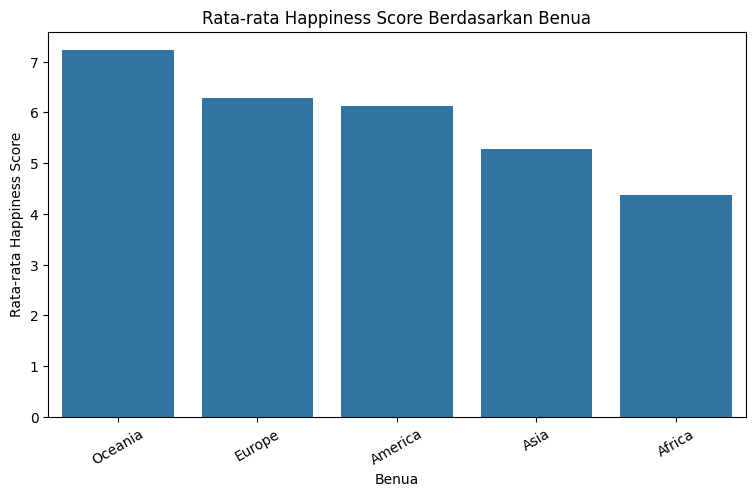

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=continent_happiness.index,
    y=continent_happiness.values
)

plt.title("Rata-rata Happiness Score Berdasarkan Benua")
plt.xlabel("Benua")
plt.ylabel("Rata-rata Happiness Score")
plt.xticks(rotation=30)

plt.show()

In [ ]:
eda_2024 = final_df[
    (final_df["Year"] == 2024) &
    (final_df["Happiness Score"].notna())
].copy()

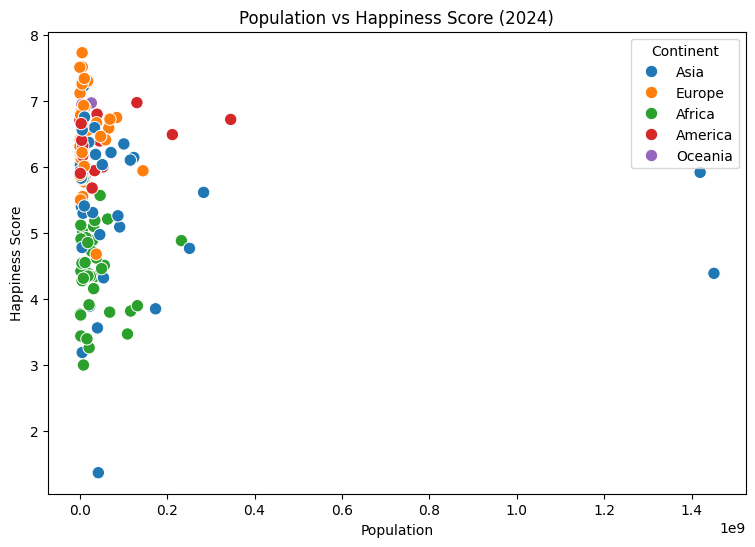

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=eda_2024,
    x="Population",
    y="Happiness Score",
    hue="Continent",
    s=80
)

plt.title("Population vs Happiness Score (2024)")
plt.xlabel("Population")
plt.ylabel("Happiness Score")

plt.show()

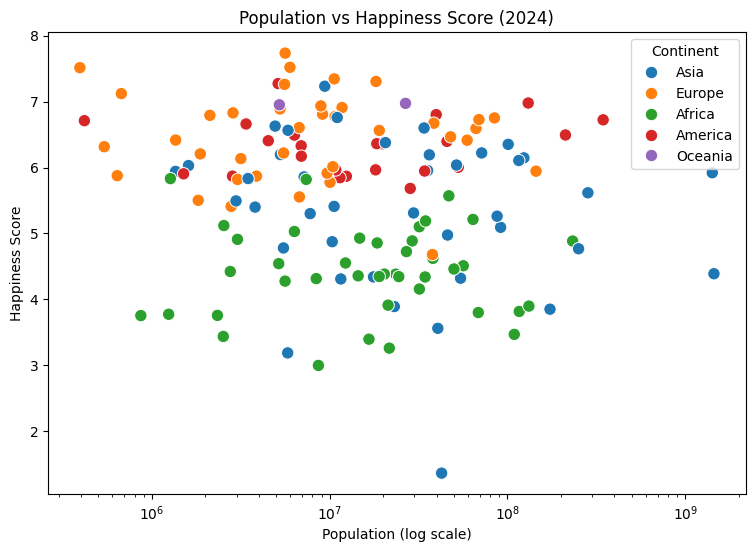

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=eda_2024,
    x="Population",
    y="Happiness Score",
    hue="Continent",
    s=80
)

plt.xscale("log")

plt.title("Population vs Happiness Score (2024)")
plt.xlabel("Population (log scale)")
plt.ylabel("Happiness Score")

plt.show()

=== CORRELATION MATRIX ===
                           Population  Land Area (Km²)  Density (P/Km²)  Happiness Score  GDP_per_Capita  Social_Support  Healthy_Life_Expectancy  Freedom  Generosity  Perceptions_of_Corruption  Dystopia_Residual
Population                       1.00             0.43             0.01            -0.06           -0.02           -0.11                    -0.02     0.03        0.05                      -0.04              -0.05
Land Area (Km²)                  0.43             1.00            -0.09             0.10            0.10            0.09                     0.03    -0.02        0.05                       0.03               0.06
Density (P/Km²)                  0.01            -0.09             1.00             0.06            0.18            0.03                     0.20     0.07        0.10                       0.26              -0.20
Happiness Score                 -0.06             0.10             0.06             1.00            0.77            0.81 

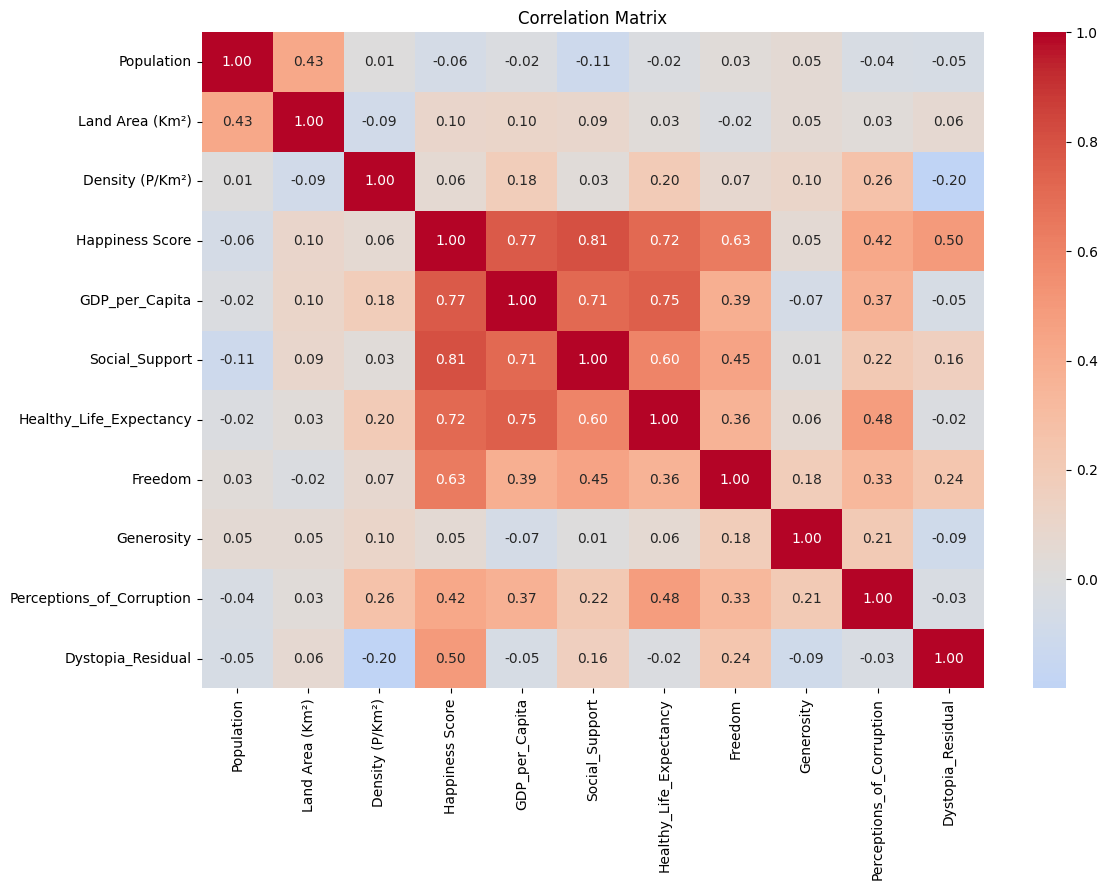

In [ ]:
corr_cols = [
    "Population",
    "Land Area (Km²)",
    "Density (P/Km²)",
    "Happiness Score",
    "GDP_per_Capita",
    "Social_Support",
    "Healthy_Life_Expectancy",
    "Freedom",
    "Generosity",
    "Perceptions_of_Corruption",
    "Dystopia_Residual"
]

# Hitung korelasi
correlation = eda_2024[corr_cols].corr()

# =========================
# OUTPUT ANGKA KORELASI
# =========================

print("=== CORRELATION MATRIX ===")
print(correlation.round(2).to_string())

print("\n=== KORELASI TERHADAP HAPPINESS SCORE ===")

happiness_corr = (
    correlation["Happiness Score"]
    .drop("Happiness Score")
    .sort_values(ascending=False)
)

print(happiness_corr.round(2).to_string())

# =========================
# HEATMAP
# =========================

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

=== CORRELATION MATRIX ===
                           Population  Land Area (Km²)  Density (P/Km²)  Happiness Score  GDP_per_Capita  Social_Support  Healthy_Life_Expectancy  Freedom  Generosity  Perceptions_of_Corruption  Dystopia_Residual
Population                       1.00             0.43             0.01            -0.06           -0.02           -0.11                    -0.02     0.03        0.05                      -0.04              -0.05
Land Area (Km²)                  0.43             1.00            -0.09             0.10            0.10            0.09                     0.03    -0.02        0.05                       0.03               0.06
Density (P/Km²)                  0.01            -0.09             1.00             0.06            0.18            0.03                     0.20     0.07        0.10                       0.26              -0.20
Happiness Score                 -0.06             0.10             0.06             1.00            0.77            0.81 

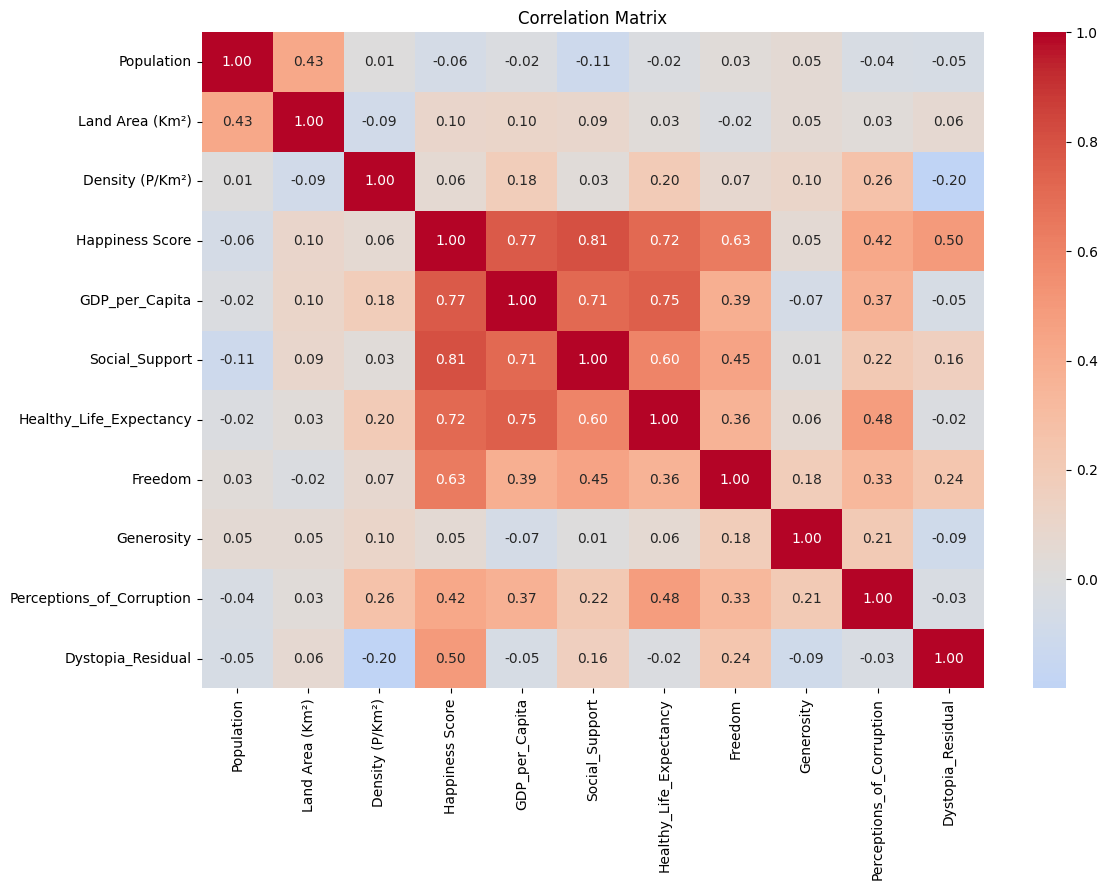